In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
eeg_data = pd.read_csv('./EEG/eeg-data.csv', low_memory=False)
eeg_data.rename(columns={'Unnamed: 0': 'index'}, inplace=True)
def extract_eeg_lists(eeg_power_str):
    return [float(n) for n in eeg_power_str.split("[")[1].split("]")[0].split(",")]
eeg_data.eeg_power = eeg_data.eeg_power.apply(extract_eeg_lists)
eeg_data.raw_values = eeg_data.raw_values.apply(extract_eeg_lists)
print(eeg_data.shape)

(30013, 13)


In [4]:
eeg_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30013 entries, 0 to 30012
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   index              30013 non-null  int64 
 1   id                 30013 non-null  int64 
 2   indra_time         30013 non-null  object
 3   browser_latency    30013 non-null  object
 4   reading_time       30013 non-null  object
 5   attention_esense   30013 non-null  int64 
 6   meditation_esense  30013 non-null  int64 
 7   eeg_power          30013 non-null  object
 8   raw_values         30013 non-null  object
 9   signal_quality     30013 non-null  int64 
 10  createdAt          30013 non-null  object
 11  updatedAt          30013 non-null  object
 12  label              30013 non-null  object
dtypes: int64(5), object(8)
memory usage: 3.0+ MB


In [16]:
eeg_data.head(1)

,index,id,indra_time,browser_latency,reading_time,attention_esense,meditation_esense,eeg_power,raw_values,signal_quality,createdAt,updatedAt,label
0,3730,12,2015-05-09 23:13:42.281,1461,2015-05-09 16:13:40.954,0,0,"[944412.0, 111373.0, 52404.0, 28390.0, 3237.0,...","[-203.0, -202.0, -196.0, -185.0, -163.0, -137....",200,2015-05-09 23:13:39.550,2015-05-09 23:13:39.549+00,unlabeled


In [15]:
seed = 42
np.random.seed(seed)
random_index = np.random.randint(0, len(eeg_data))
print(f"size of each eeg power: {len(eeg_data.eeg_power[random_index])}")
print(f"size of each raw value: {len(eeg_data.raw_values[random_index])}")

size of each eeg power: 8
size of each raw value: 512


In [31]:
print(f"Number of IDs: {len(list(eeg_data.id.value_counts().keys()))}")
print(f"Number of records: {len(list(eeg_data.index.value_counts().keys()))}")
print(f"Number of labels: {len(list(eeg_data.label.value_counts().keys()))}")

Number of IDs: 30
Number of records: 30013
Number of labels: 68


In [ ]:
import ast

min_eeg_power = ast.literal_eval(
    eeg_data.loc[eeg_data.signal_quality.eq(eeg_data.signal_quality.min()), "eeg_power"].iloc[0]
)[0]
max_eeg_power = ast.literal_eval(
    eeg_data.loc[eeg_data.signal_quality.eq(eeg_data.signal_quality.max()), "eeg_power"].iloc[0]
)[0]

print(float(min_eeg_power))
# plt.scatter(max_eeg_power, min_eeg_power)
# plt.xlabel("eeg_power at max signal_quality (first band)")
# plt.ylabel("eeg_power at min signal_quality (first band)")
# plt.scatter(eeg_data.eeg_power[eeg_data.signal_quality == eeg_data.signal_quality.max()].iloc[0],
            # eeg_data.eeg_power[eeg_data.signal_quality == eeg_data.signal_quality.min()].iloc[0])

# Stimulus


In [34]:
stim_data = pd.read_csv('./EEG/stimulus-times.csv', low_memory=False)
print(stim_data.shape)
stim_data.head(2)

(131, 2)


,event name,time
0,everyone paired,2015-05-09 23:26:34.35+00
1,blinkInstruction,2015-05-09 23:32:36.911+00


# Subject Metadata


In [35]:
subject_data = pd.read_csv("./EEG/subject-metadata.csv", low_memory=False)
print(subject_data.shape)
subject_data.head(2)

(30, 7)


,ID,Session,Seen video before?,Chosen color,Saw icons?,Gender,Wear contacts
0,1,1,n,b,n,f,n
1,2,1,n,b,n,m,n


In [37]:
subject_data.Session.value_counts()

Session
1    15
2    15
Name: count, dtype: int64

In [38]:
subject_data['Seen video before?'].value_counts()

Seen video before?
n    25
y     5
Name: count, dtype: int64

In [39]:
subject_data['Chosen color'].value_counts()

Chosen color
b    16
r     7
g     6
y     1
Name: count, dtype: int64

In [41]:
subject_data['Saw icons?'].value_counts()

Saw icons?
n         20
smiley     5
both       4
star       1
Name: count, dtype: int64

In [42]:
subject_data['Wear contacts'].value_counts()

Wear contacts
n    26
y     4
Name: count, dtype: int64

In [43]:
subject_data.Gender.value_counts()

Gender
m    23
f     7
Name: count, dtype: int64

In [44]:
# Compact profile for subject_data
display(subject_data.shape)
display(subject_data.info())
display(subject_data.describe(include='all').T)

summary = pd.DataFrame({
    'dtype': subject_data.dtypes.astype(str),
    'missing': subject_data.isna().sum(),
    'missing_pct': (subject_data.isna().mean() * 100).round(2),
    'unique': subject_data.nunique(dropna=True)
}).sort_values(['missing_pct', 'unique'], ascending=[False, False])

display(summary)

(30, 7)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   ID                  30 non-null     int64 
 1   Session             30 non-null     int64 
 2   Seen video before?  30 non-null     object
 3   Chosen color        30 non-null     object
 4   Saw icons?          30 non-null     object
 5   Gender              30 non-null     object
 6   Wear contacts       30 non-null     object
dtypes: int64(2), object(5)
memory usage: 1.8+ KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,30.0,NaN,NaN,NaN,15.5,8.803408,1.0,8.25,15.5,22.75,30.0
Session,30.0,NaN,NaN,NaN,1.5,0.508548,1.0,1.0,1.5,2.0,2.0
Seen video before?,30,2,n,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Chosen color,30,4,b,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Saw icons?,30,4,n,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,30,2,m,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Wear contacts,30,2,n,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,dtype,missing,missing_pct,unique
ID,int64,0,0.0,30
Chosen color,object,0,0.0,4
Saw icons?,object,0,0.0,4
Session,int64,0,0.0,2
Seen video before?,object,0,0.0,2
Gender,object,0,0.0,2
Wear contacts,object,0,0.0,2


,field,category,count,pct,total
2,Chosen color,Blue,16,53.333333,30
3,Chosen color,Red,7,23.333333,30
4,Chosen color,Green,6,20.000000,30
5,Chosen color,Yellow,1,3.333333,30
10,Gender,Male,23,76.666667,30
11,Gender,Female,7,23.333333,30
6,Saw icons?,No,20,66.666667,30
7,Saw icons?,Smiley,5,16.666667,30
8,Saw icons?,Both,4,13.333333,30
9,Saw icons?,Star,1,3.333333,30


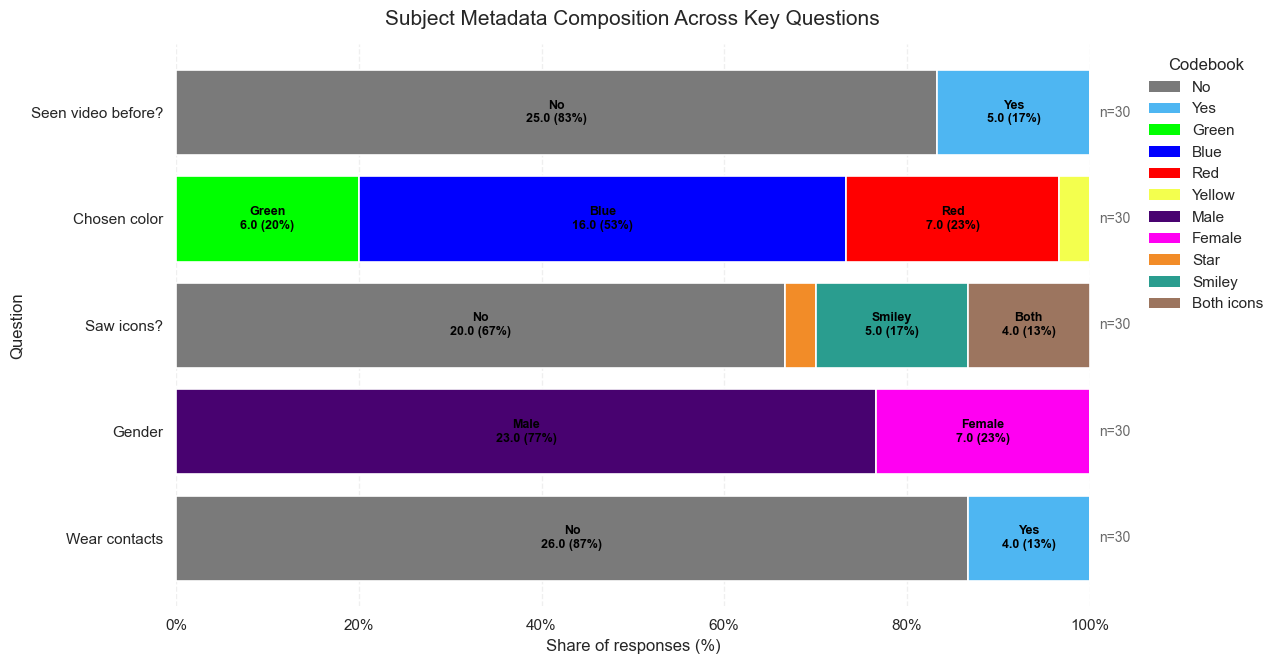

In [63]:
from matplotlib.patches import Patch

focus_cols = [
    'Seen video before?',
    'Chosen color',
    'Saw icons?',
    'Gender',
    'Wear contacts'
]

color_map = {
    'No': '#7A7A7A',
    'Yes': "#4EB6F2",
    'Yellow': "#F3FF4E",
    'Green': "#00FF00",
    'Blue': "#0000FF",
    'Red': '#FF0000',
    'Male': "#480270",
    'Female': "#FF00F2",
    'Star': '#F28C28',
    'Smiley': '#2A9D8F',
    'Both': '#9C755F',
    'Missing': '#D9D9D9'
}

legend_labels = {
    'No': 'No',
    'Yes': 'Yes',
    'Yellow': 'Yellow',
    'Green': 'Green',
    'Blue': 'Blue',
    'Red': 'Red',
    'Male': 'Male',
    'Female': 'Female',
    'Star': 'Star',
    'Smiley': 'Smiley',
    'Both': 'Both icons',
    'Missing': 'Missing'
}

def encode_response(field, value):
    if pd.isna(value):
        return 'Missing'

    text = str(value).strip().lower()

    if field in ['Seen video before?', 'Wear contacts']:
        if text in ['yes', 'y', 'true', '1']:
            return 'Yes'
        if text in ['no', 'n', 'false', '0']:
            return 'No'
    elif field == 'Saw icons?':
        icon_lookup = {
            'n': 'No',
            'no': 'No',
            'star': 'Star',
            'smiley': 'Smiley',
            'both': 'Both'
        }
        return icon_lookup.get(text, text[:1].lower())
    elif field == 'Chosen color':
        color_lookup = {
            'y': 'Yellow',
            'g': 'Green',
            'b': 'Blue',
            'r': 'Red'
        }
        return color_lookup.get(text, text[:1].lower())
    elif field == 'Gender':
        gender_lookup = {
            'male': 'Male',
            'm': 'Male',
            'female': 'Female',
            'f': 'Female'
        }
        return gender_lookup.get(text, text[:1].lower())

    return text[:1].lower()

plot_df = subject_data[focus_cols].copy()

records = []
for field in focus_cols:
    coded = plot_df[field].apply(lambda value: encode_response(field, value))
    counts = coded.value_counts(dropna=False)
    total = counts.sum()
    for category, count in counts.items():
        records.append({
            'field': field,
            'category': category,
            'count': int(count),
            'pct': count / total * 100,
            'total': int(total)
        })

dist_df = pd.DataFrame(records)
display(dist_df.sort_values(['field', 'pct'], ascending=[True, False]))

category_order = ['No', 'Yes', 'Green', 'Blue', 'Red', 'Yellow', 'Male', 'Female', 'Star', 'Smiley', 'Both', 'Missing']
active_categories = [
    category for category in category_order
    if category in dist_df['category'].unique()
 ]

pivot_pct = dist_df.pivot(index='field', columns='category', values='pct').fillna(0)
pivot_count = dist_df.pivot(index='field', columns='category', values='count').fillna(0)
pivot_pct = pivot_pct.reindex(index=focus_cols, columns=active_categories, fill_value=0)
pivot_count = pivot_count.reindex(index=focus_cols, columns=active_categories, fill_value=0)

fig, ax = plt.subplots(figsize=(13, 6.8))
left = np.zeros(len(pivot_pct))

for category in active_categories:
    widths = pivot_pct[category].values
    bars = ax.barh(
        pivot_pct.index,
        widths,
        left=left,
        color=color_map[category],
        edgecolor='white',
        linewidth=1.2
    )
    counts = pivot_count[category].values
    for bar, width, count in zip(bars, widths, counts):
        if width >= 7:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + bar.get_height() / 2,
                f'{category}\n{count} ({width:.0f}%)',
                ha='center',
                va='center',
                fontsize=9,
                fontweight='bold',
                color='black'
            )
    left += widths

ax.set_xlim(0, 100)
ax.set_xlabel('Share of responses (%)')
ax.set_ylabel('Question')
ax.set_title('Subject Metadata Composition Across Key Questions', fontsize=15, pad=14)
ax.xaxis.set_major_formatter(lambda value, pos: f'{value:.0f}%')
ax.grid(axis='x', linestyle='--', alpha=0.3)
ax.grid(axis='y', visible=False)
ax.invert_yaxis()

totals = dist_df.groupby('field')['total'].first().reindex(focus_cols)
for idx, total in enumerate(totals.values):
    ax.text(101, idx, f'n={total}', va='center', fontsize=10, color='dimgray')

legend_handles = [
    Patch(facecolor=color_map[category], edgecolor='none', label=legend_labels[category])
    for category in active_categories
 ]
ax.legend(
    handles=legend_handles,
    title='Codebook',
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    frameon=False
 )

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()